# Fertilizer Recommendation System
#### Life cycle of Machine Learning Project
- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model
### 1) Problem statement
- Farmers struggle to select the optimal fertilizer due to varying soil characteristics (N, P, K, PH), crop needs, and environmental conditions. This project aims to develop a data-driven model that analyzes this data to recommend the most effective fertilizer, thereby maximizing crop yield and minimizing waste.
### 2) Data Collection
- Data source - https://www.kaggle.com/datasets/nishchalchandel/fertilizer-recommendation
- The data consists of 12 column and 3369 rows.


### 2.1 Import Data and Required Packages

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Import the CSV Data as Pandas DataFrame
df = pd.read_csv("G:/Graduation Project/Fertilizer_Recommendation_System/notebook/data/Fertilizer_recommendation_dataset.csv")

df.head()  # Show top 5 rows

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [34]:
df.shape

(3369, 12)

### 2.2 Dataset information
- Temperature: in degree
- Moisture
- Rainfall: in mm
- ph: Acidity level
- Nitrogen
- Phosphorous
- Potassium
- Carbon
- Soil: type of soil
- Crop: type of crop
- Fertilizer: The recommended fertilizer type
- Remark: A description or reason for the fertilizer recommendation

### 3. Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [35]:
df.isna().sum()

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

**Insights:**
There is no missing values

### 3.2 Check Duplicates

In [36]:
df.duplicated().sum()

np.int64(0)

**Insights:**
There is no duplication

### 3.3 Check data types

In [37]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3369 entries, 0 to 3368
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3369 non-null   float64
 1   Moisture     3369 non-null   float64
 2   Rainfall     3369 non-null   float64
 3   PH           3369 non-null   float64
 4   Nitrogen     3369 non-null   float64
 5   Phosphorous  3369 non-null   float64
 6   Potassium    3369 non-null   float64
 7   Carbon       3369 non-null   float64
 8   Soil         3369 non-null   object 
 9   Crop         3369 non-null   object 
 10  Fertilizer   3369 non-null   object 
 11  Remark       3369 non-null   object 
dtypes: float64(8), object(4)
memory usage: 316.0+ KB


### 3.4 Checking the number of unique values of each column

In [38]:
df.nunique()

Temperature    3206
Moisture       3220
Rainfall       3219
PH             3067
Nitrogen       3047
Phosphorous    3070
Potassium      3020
Carbon         3162
Soil              5
Crop             34
Fertilizer       10
Remark           11
dtype: int64

### 3.5 Check statistics of data set

In [39]:
df.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.000000
mean,26.773073,0.613663,114.368122,6.405814,61.277352,67.965815,68.108161,1.487022
std,8.954719,0.147372,76.963186,0.958979,10.222392,41.067789,34.347909,0.676748
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,21.797647,0.502644,64.563755,5.872317,54.666298,42.253285,49.432714,0.998436
50%,25.722676,0.616935,100.786971,6.361376,59.524483,57.509482,57.236066,1.487129
75%,29.625116,0.724621,149.675285,6.923032,66.506292,81.518033,73.786553,1.984629
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


### 3.6 Data Quality Check (Negative Values)

**Observation:**
From the `df.describe()` output above, we can see that the `min` value for `Rainfall`, `Phosphorous`, `Potassium`, and `Carbon` is negative. This is physically impossible for these measurements and indicates a data quality issue that needs to be addressed.

In [69]:
# Identify columns with potential negative values
cols_with_negatives = ['Rainfall', 'Phosphorous', 'Potassium', 'Carbon']

print("Count of negative values before cleaning:")
for col in cols_with_negatives:
    print(f"{col}: {(df[col] < 0).sum()}")

# Strategy: Replace negative values with 0.
# Negative values for physical measurements are likely data entry errors. 
# We will replace them with 0, assuming they represent an absence or a floor value (0).

for col in cols_with_negatives:
    df[col] = df[col].apply(lambda x: 0 if x < 0 else x)

print("\n--- Data Cleaned: Negative values replaced with 0 ---")

# Display statistics again to confirm negative values are gone
print("\nStatistics after cleaning negative values:")
print(df[cols_with_negatives].describe())

Count of negative values before cleaning:
Rainfall: 75
Phosphorous: 78
Potassium: 71
Carbon: 85

--- Data Cleaned: Negative values replaced with 0 ---

Statistics after cleaning negative values:
          Rainfall  Phosphorous    Potassium       Carbon
count  3369.000000  3369.000000  3369.000000  3369.000000
mean    116.177788    68.837492    68.540380     1.494101
std      73.151319    39.172075    33.344147     0.659465
min       0.000000     0.000000     0.000000     0.000000
25%      64.563755    42.253285    49.432714     0.998436
50%     100.786971    57.509482    57.236066     1.487129
75%     149.675285    81.518033    73.786553     1.984629
max     411.955947   177.314481   161.067982     3.241984


### 3.6 Check correlations of data set

In [40]:
df.corr(numeric_only=True)

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
Temperature,1.000000,-0.058173,-0.045586,0.014955,0.104473,0.062109,0.053607,0.005345
Moisture,-0.058173,1.000000,0.148668,0.053211,0.028227,-0.031561,-0.010107,0.029300
Rainfall,-0.045586,0.148668,1.000000,-0.120730,0.452978,-0.073488,0.130924,0.023062
PH,0.014955,0.053211,-0.120730,1.000000,-0.136355,0.251167,0.227729,0.033825
Nitrogen,0.104473,0.028227,0.452978,-0.136355,1.000000,0.089124,0.167672,-0.020639
Phosphorous,0.062109,-0.031561,-0.073488,0.251167,0.089124,1.000000,0.489989,-0.038937
Potassium,0.053607,-0.010107,0.130924,0.227729,0.167672,0.489989,1.000000,0.012531
Carbon,0.005345,0.029300,0.023062,0.033825,-0.020639,-0.038937,0.012531,1.000000


### 3.7 Exploring Data

In [41]:
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [42]:
print(f"We have data for {df.Fertilizer.unique().size} fertilizer")

We have data for 10 fertilizer


In [43]:
print(f"We have data for {df.Crop.unique().size} crops")

We have data for 34 crops


In [44]:
print(f"Categories in 'Fertilizer' variable: {df['Fertilizer'].unique()}")

Categories in 'Fertilizer' variable: ['Compost' 'Balanced NPK Fertilizer' 'Water Retaining Fertilizer'
 'Organic Fertilizer' 'Gypsum' 'Lime' 'DAP' 'Urea' 'Muriate of Potash'
 'General Purpose Fertilizer']


In [45]:
print(f"Categories in 'crop' variable: {df['Crop'].unique()}")

Categories in 'crop' variable: ['rice' 'wheat' 'Mung Bean' 'Tea' 'millet' 'maize' 'Lentil' 'Jute'
 'Coffee' 'Cotton' 'Ground Nut' 'Peas' 'Rubber' 'Sugarcane' 'Tobacco'
 'Kidney Beans' 'Moth Beans' 'Coconut' 'Black gram' 'Adzuki Beans'
 'Pigeon Peas' 'Chickpea' 'banana' 'grapes' 'apple' 'mango' 'muskmelon'
 'orange' 'papaya' 'pomegranate' 'watermelon' 'potatoes' 'tomatoes'
 'berseem clover']


In [46]:
df.Fertilizer.value_counts()

Fertilizer
DAP                           1131
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              374
Balanced NPK Fertilizer        257
Lime                           206
Urea                           154
Organic Fertilizer              95
Gypsum                          71
General Purpose Fertilizer      31
Name: count, dtype: int64

In [48]:
df.Crop.value_counts()

Crop
potatoes          123
rice              100
wheat             100
Mung Bean         100
millet            100
Tea               100
Lentil            100
Jute              100
Coffee            100
maize             100
Ground Nut        100
Peas              100
Rubber            100
Sugarcane         100
Tobacco           100
Kidney Beans      100
Moth Beans        100
Cotton            100
Coconut           100
Black gram        100
Pigeon Peas       100
Adzuki Beans      100
banana            100
grapes            100
apple             100
Chickpea          100
mango             100
muskmelon         100
papaya            100
orange            100
pomegranate       100
watermelon        100
berseem clover     74
tomatoes           72
Name: count, dtype: int64

In [71]:
# Analyze the 'Remark' column in relation to 'Fertilizer'
print("Unique values in 'Fertilizer':", df['Fertilizer'].nunique())
print("Unique values in 'Remark':", df['Remark'].nunique())

# Check if 'Remark' is just a textual description of 'Fertilizer'
# This crosstab will show how many times each fertilizer maps to each remark
crosstab_remark = pd.crosstab(df['Fertilizer'], df['Remark'])
print("\nCrosstab: Fertilizer vs. Remark")
print(crosstab_remark)

Unique values in 'Fertilizer': 10
Unique values in 'Remark': 11

Crosstab: Fertilizer vs. Remark
Remark                      "Provides a balanced mix of nitrogen, phosphorus, and potassium for loamy soils. Prefer this for general-purpose fertilization in well-structured soils."  \
Fertilizer                                                                                                                                                                              
Balanced NPK Fertilizer                                                   100                                                                                                           
Compost                                                                     0                                                                                                           
DAP                                                                         0                                                                                      

**Observation:**
The crosstab shows a strong, almost one-to-one mapping between `Fertilizer` and `Remark`. This confirms that 'Remark' is a textual explanation *of* the target variable ('Fertilizer'), not a feature *to predict* it. 

**Conclusion:** The `Remark` column is redundant for model training and should be dropped during the preprocessing phase.

In [49]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 8 numerical features : ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']

We have 4 categorical features : ['Soil', 'Crop', 'Fertilizer', 'Remark']


### 4. Exploring Data ( Visualization )
- Target Variable Analysis (Fertilizer Distribution)
- Numerical Features Distribution
- Feature vs. Target Analysis (Fertilizer Requirements)
- Correlation Analysis (Heatmap)

In [50]:
# Set the style for all plots
sns.set(style="whitegrid")

#### 4.1 Target Variable Analysis (Fertilizer Distribution)

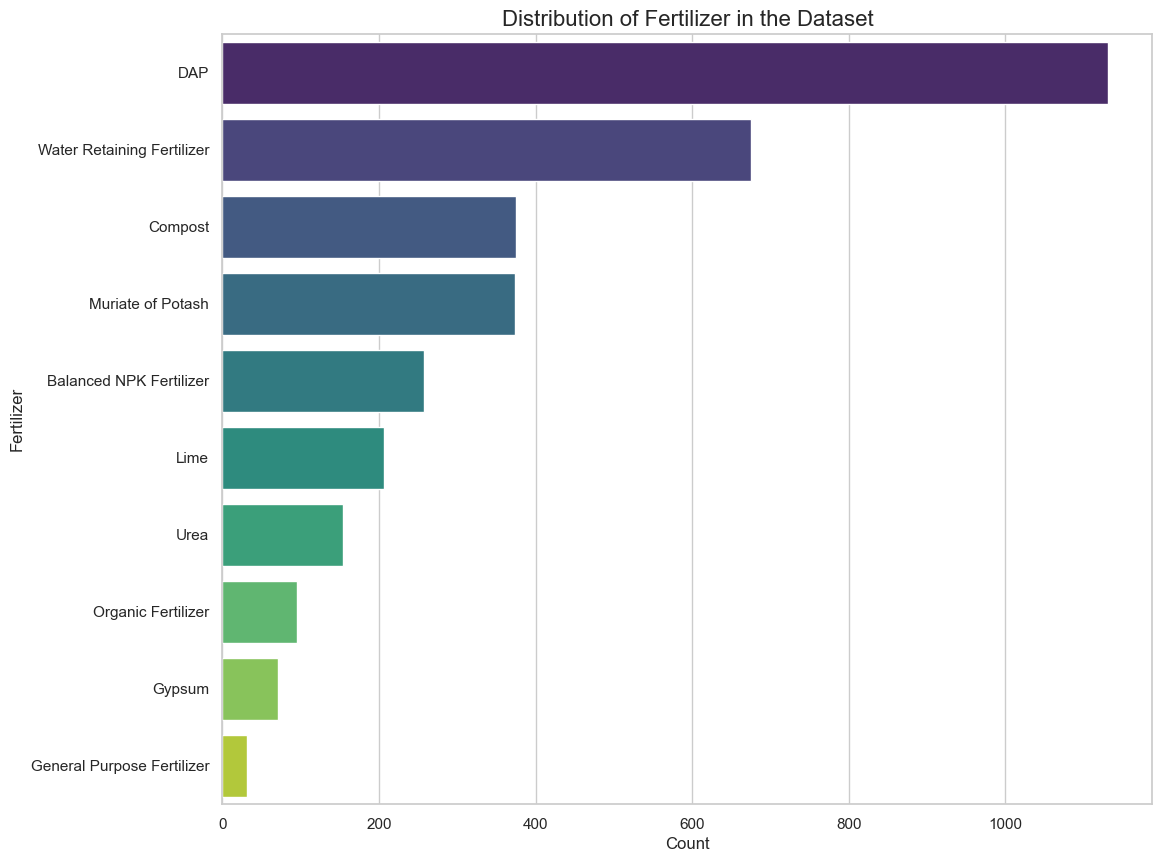

In [53]:
plt.figure(figsize=(12, 10))
sns.countplot(y='Fertilizer', data=df, order = df['Fertilizer'].value_counts().index, palette='viridis')
plt.title('Distribution of Fertilizer in the Dataset', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Fertilizer', fontsize=12)
plt.savefig('1_Fertilizer_distribution_plot.png')
plt.show()

**Observation (Data Imbalance):**
The distribution of the target variable `Fertilizer` is highly **imbalanced**. 
- `DAP` and `Water Retaining Fertilizer` have a significantly higher number of samples.
- `General Purpose Fertilizer` and `Gypsum` have very few samples.

**Implication:** This imbalance must be addressed during model training to prevent the model from being biased towards the majority classes. Techniques like **SMOTE (Synthetic Minority Over-sampling Technique)**, random oversampling, or using appropriate class weights and evaluation metrics (e.g., F1-score, Precision-Recall Curve) will be necessary.

#### 4.2 Numerical Features Distribution

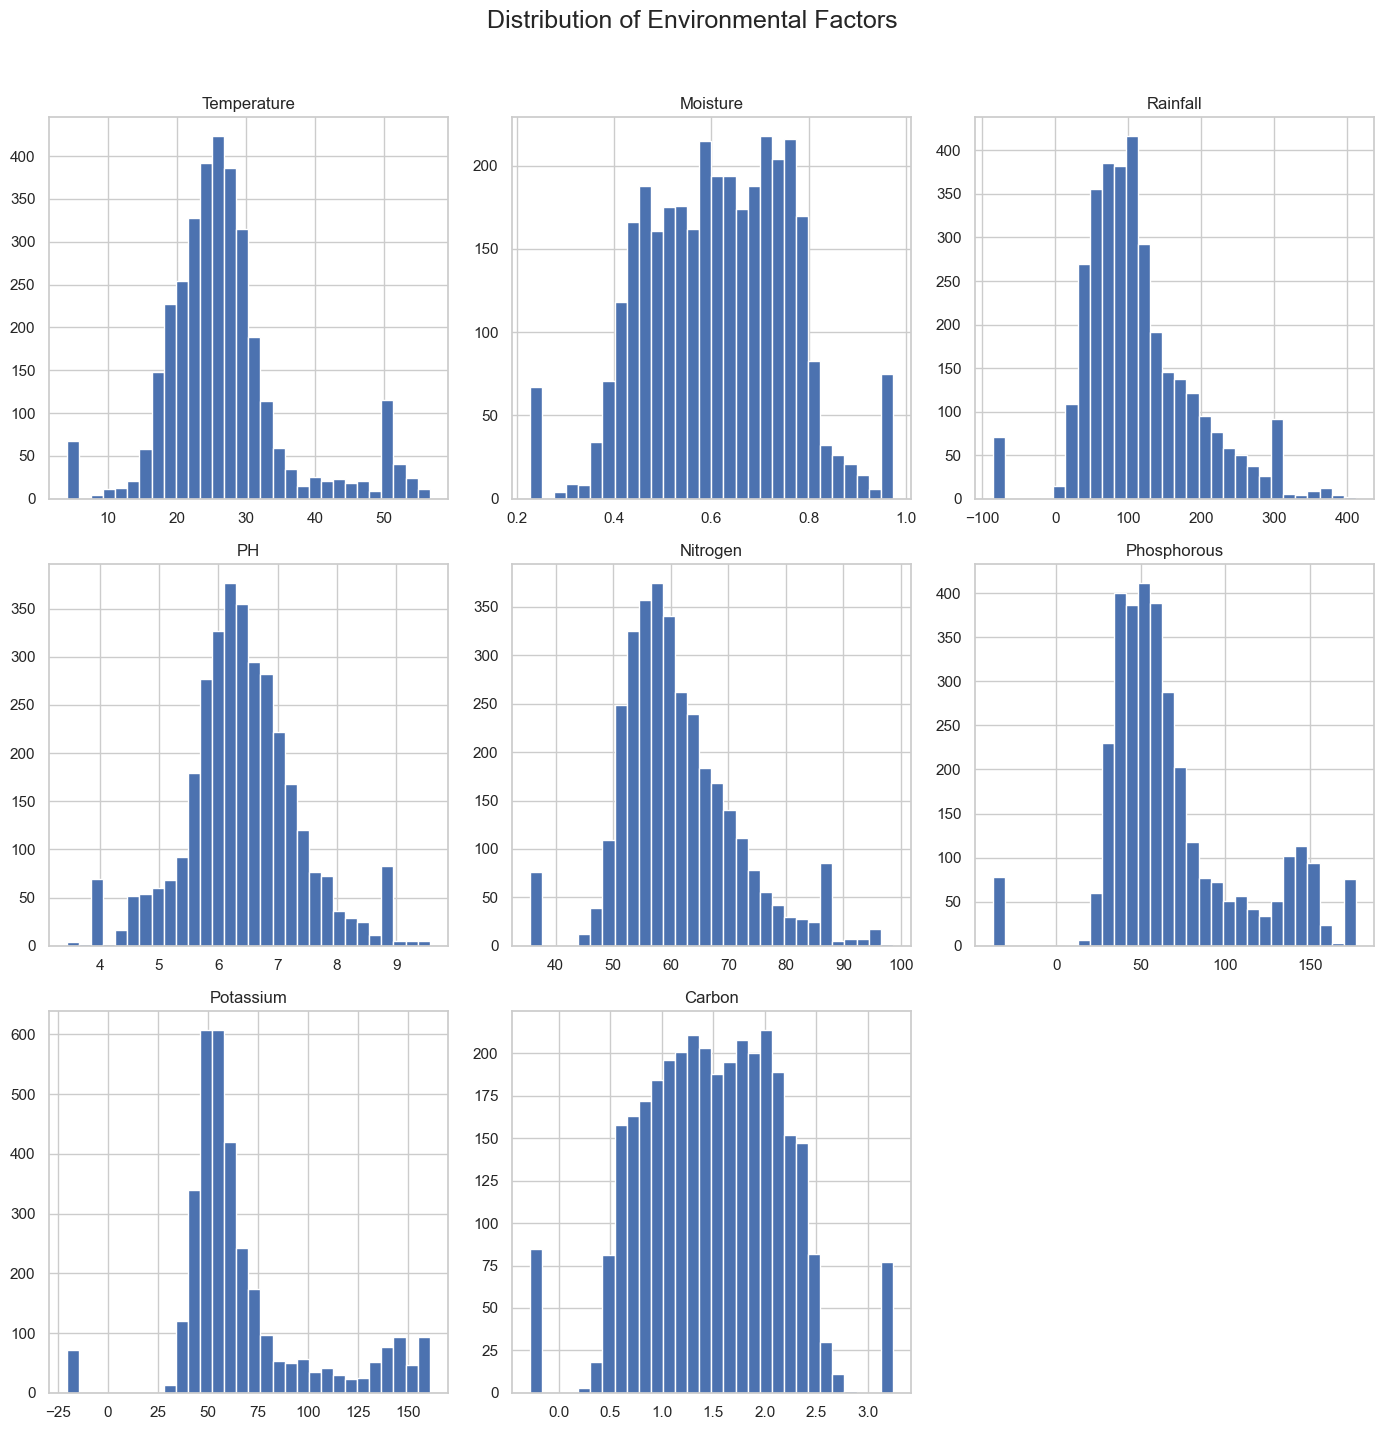

In [54]:
df.hist(figsize=(14, 14), bins=30, layout=(3, 3))
plt.suptitle('Distribution of Environmental Factors', y=1.02, fontsize=18)
plt.tight_layout()
plt.savefig('2_features_histograms.png')
plt.show()

**Observation from Histograms:**
- The cleaning step (Cell 21) was successful. The histograms for `Rainfall`, `Phosphorous`, `Potassium`, and `Carbon` now correctly start from 0.
- `Temperature`, `Moisture`, and `PH` appear to have relatively normal or bimodal distributions.
- `Nitrogen`, `Phosphorous`, `Potassium`, and `Rainfall` are skewed, which is common for environmental data.

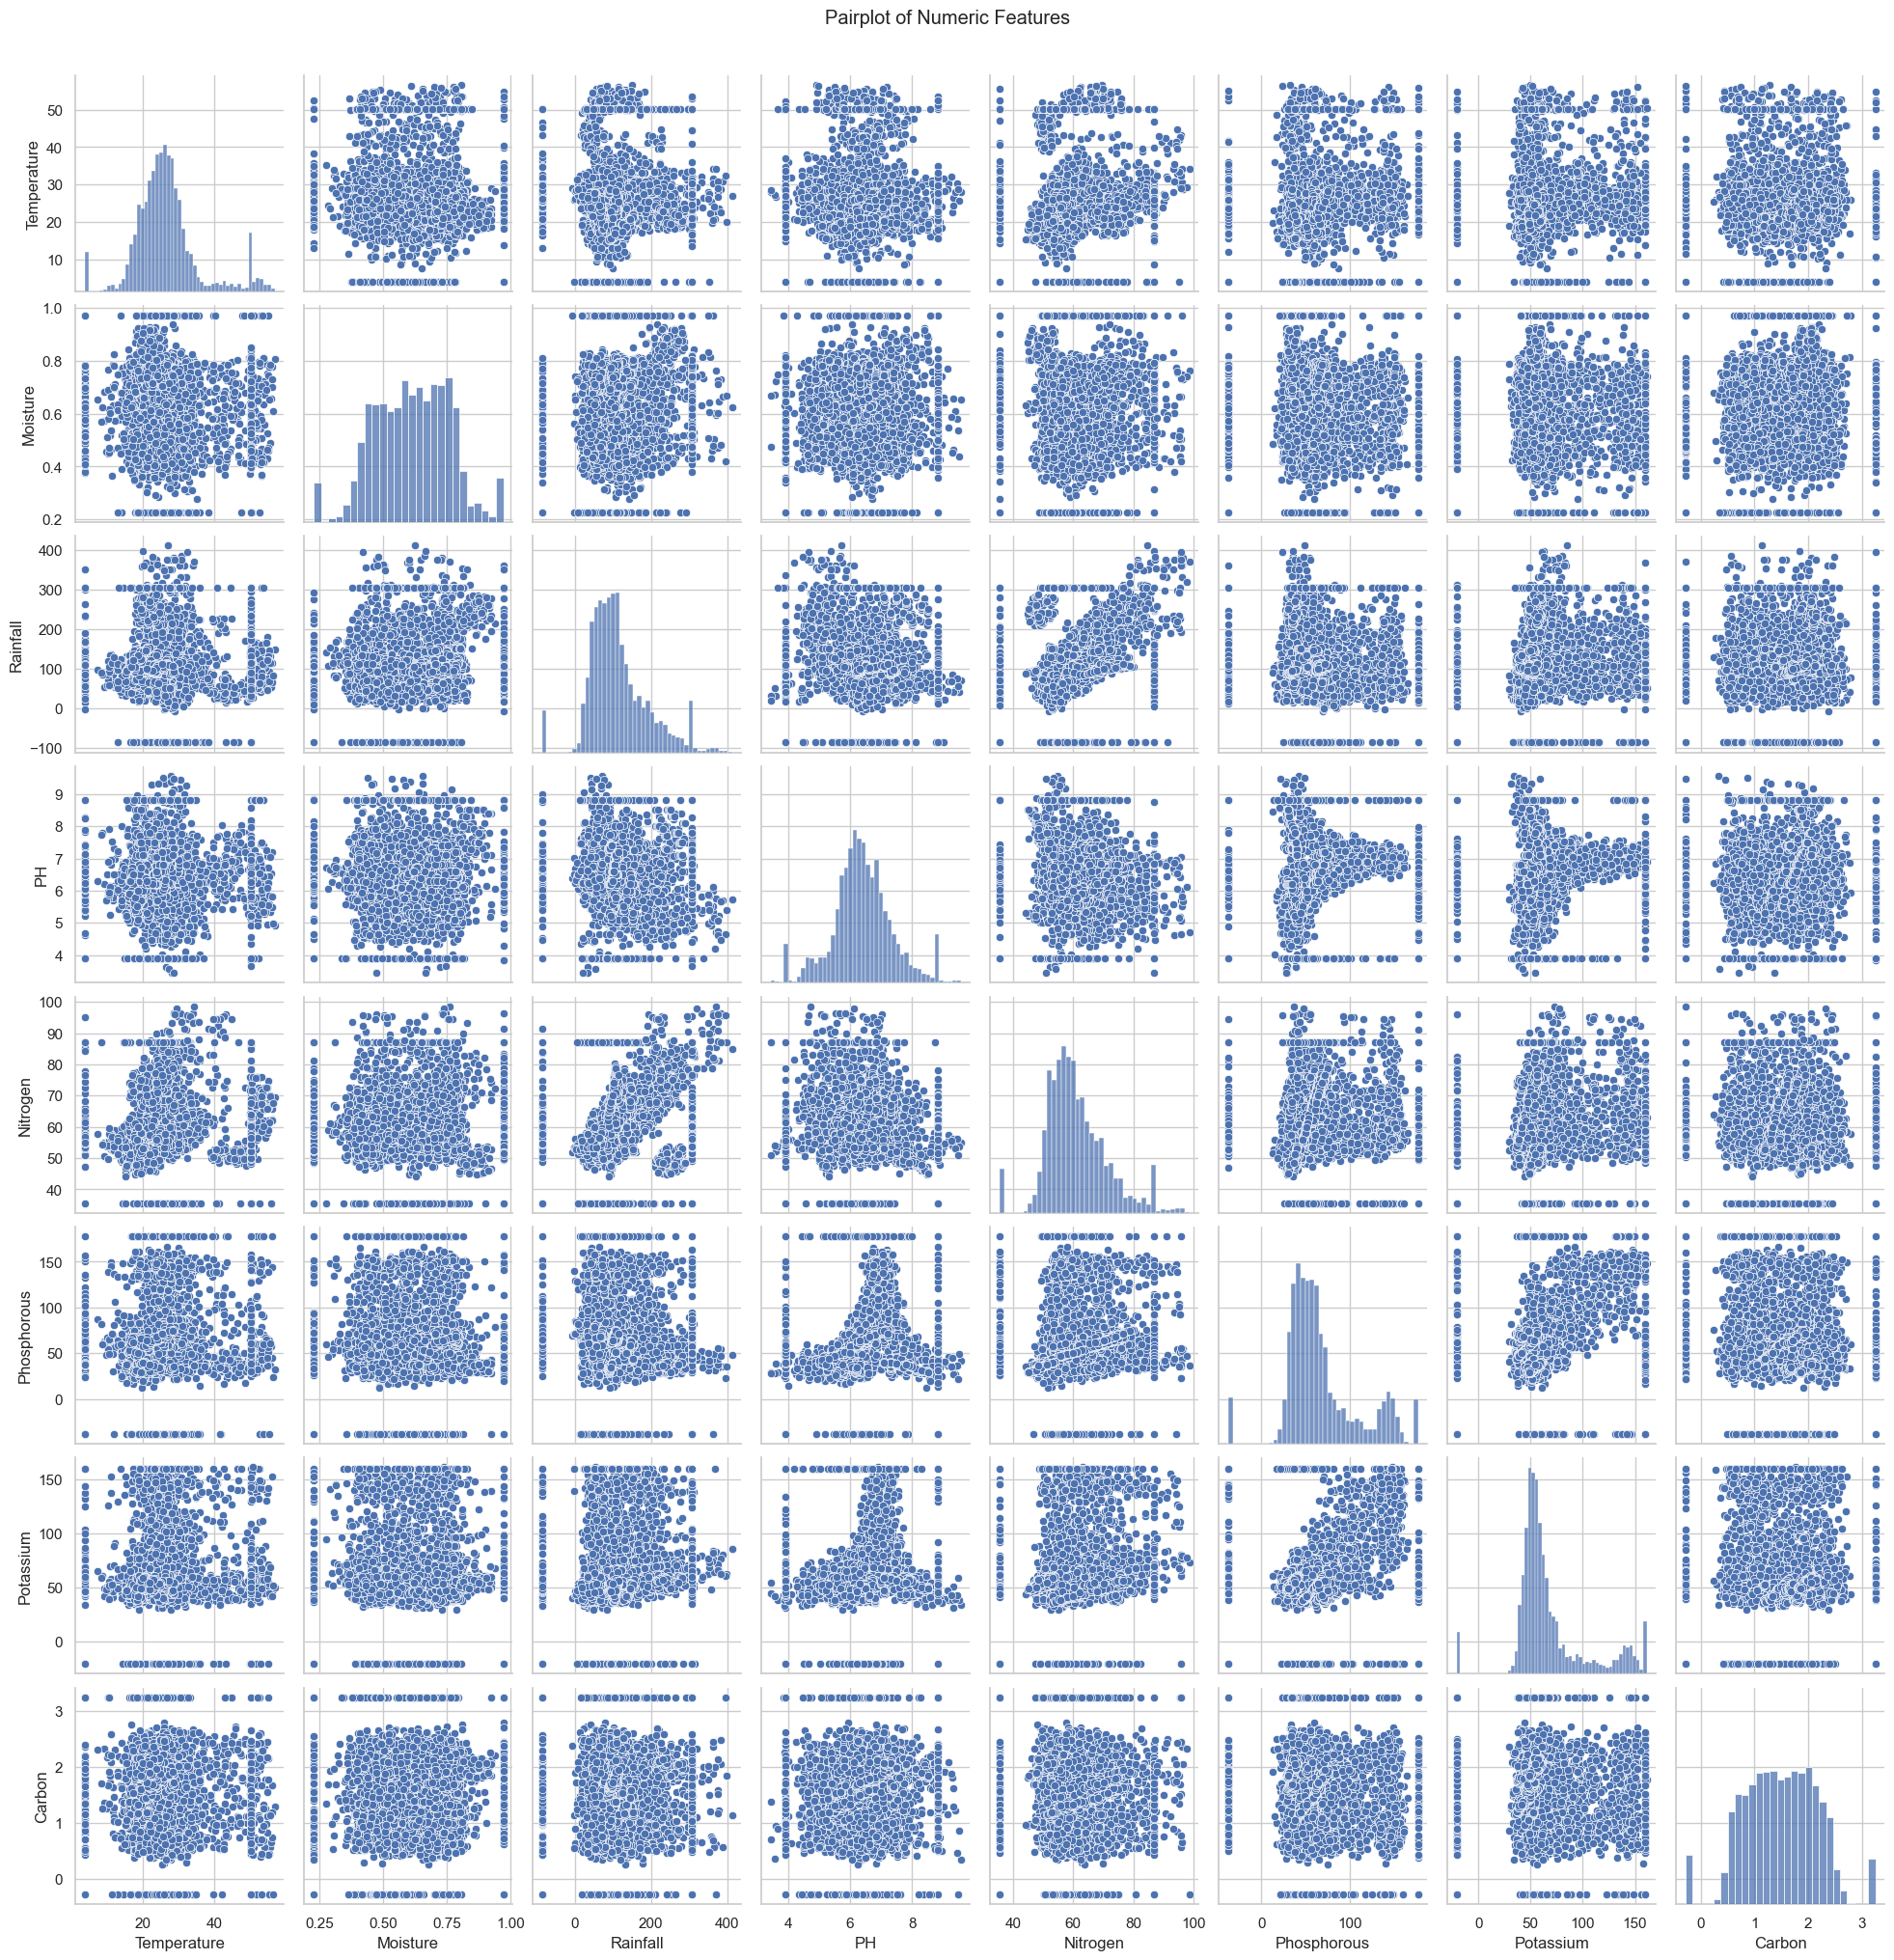

In [56]:
# Pairplot for numeric features to see relationships
numeric_df = df.select_dtypes(include=[np.number])
sns.pairplot(numeric_df)
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.savefig('2.2_features_histograms.png')
plt.show()

Categories in 'Soil' variable:
 Soil
Acidic Soil      1581
Neutral Soil      610
Loamy Soil        541
Peaty Soil        537
Alkaline Soil     100
Name: count, dtype: int64


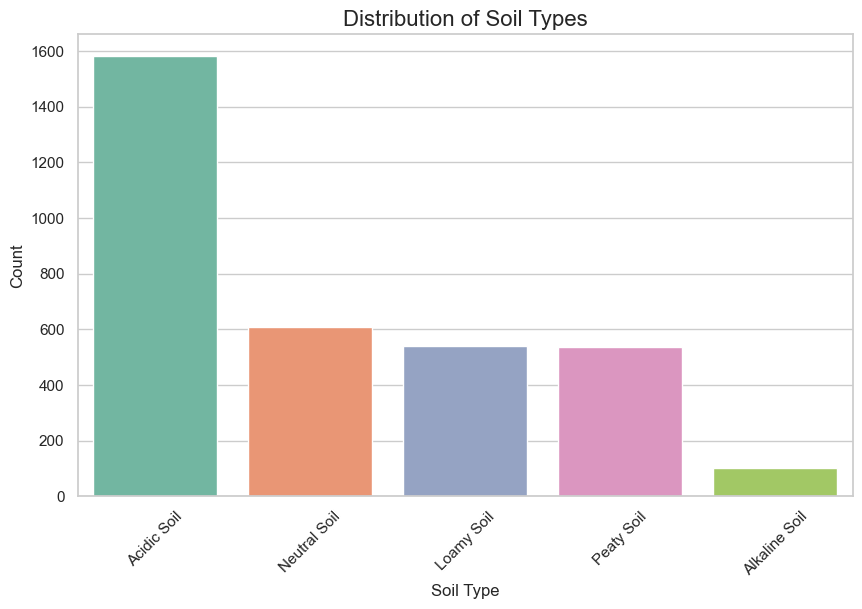

In [70]:
# Check unique values for 'Soil'
print("Categories in 'Soil' variable:\n", df['Soil'].value_counts())

# Plot the distribution of Soil Types
plt.figure(figsize=(10, 6))
sns.countplot(x='Soil', data=df, palette='Set2', order=df['Soil'].value_counts().index)
plt.title('Distribution of Soil Types', fontsize=16)
plt.xlabel('Soil Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Count plots for categorical features: Soil, Crop, Fertilizer

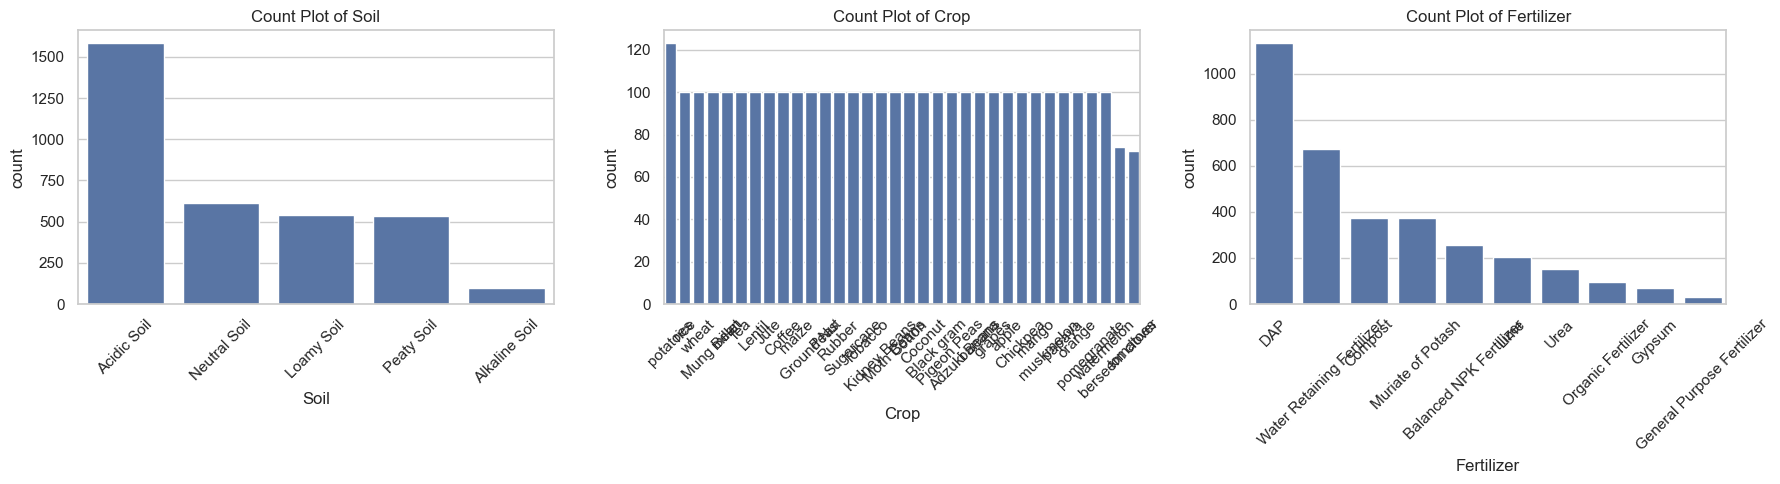

In [58]:
categorical_columns = ['Soil', 'Crop', 'Fertilizer']

plt.figure(figsize=(18, 5))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
plt.savefig('2.3_features_histograms.png')
plt.tight_layout()
plt.show()

#### 4.3 Feature vs. Target Analysis (Crop Requirements)

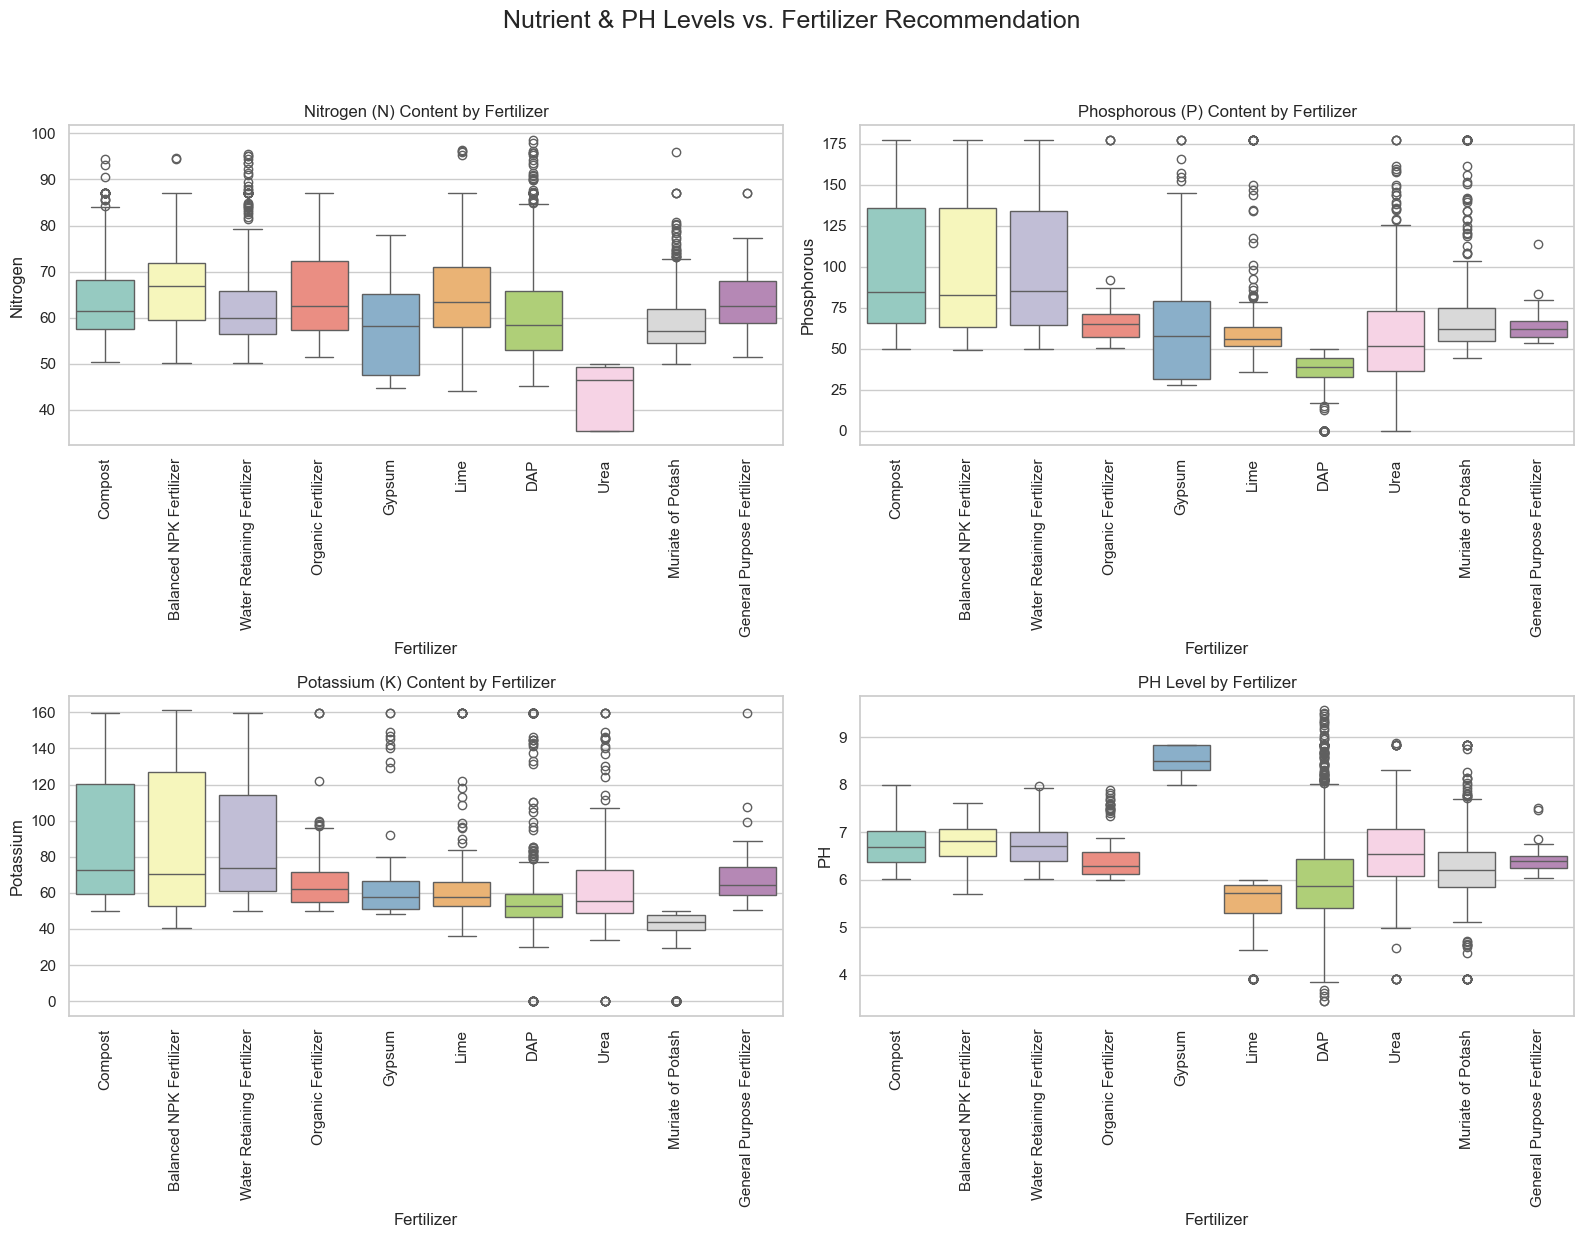

In [72]:
# Set up the figure for subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Nutrient & PH Levels vs. Fertilizer Recommendation', y=1.03, fontsize=18)

# N vs Fertilizer
sns.boxplot(ax=axes[0, 0], x='Fertilizer', y='Nitrogen', data=df, palette='Set3')
axes[0, 0].set_title('Nitrogen (N) Content by Fertilizer')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=90)

# P vs Fertilizer
sns.boxplot(ax=axes[0, 1], x='Fertilizer', y='Phosphorous', data=df, palette='Set3')
axes[0, 1].set_title('Phosphorous (P) Content by Fertilizer')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=90)

# K vs Fertilizer
sns.boxplot(ax=axes[1, 0], x='Fertilizer', y='Potassium', data=df, palette='Set3')
axes[1, 0].set_title('Potassium (K) Content by Fertilizer')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)

# PH vs Fertilizer
sns.boxplot(ax=axes[1, 1], x='Fertilizer', y='PH', data=df, palette='Set3')
axes[1, 1].set_title('PH Level by Fertilizer')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.savefig('3_boxplots_features_vs_target.png')
plt.show()

#### 4.4 Relationship between Soil and Fertilizer (New)

Let's visualize the relationship between Soil Type and the recommended Fertilizer.

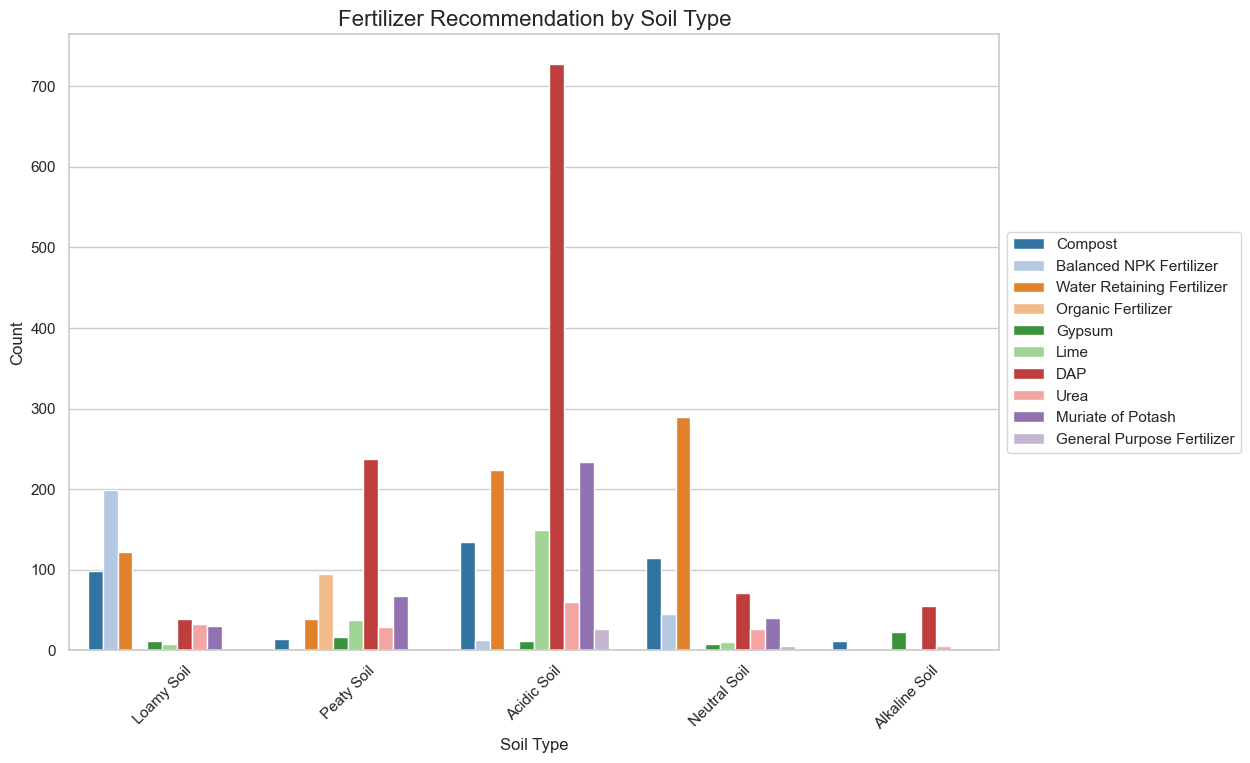

In [73]:
# Relationship between Soil and Fertilizer
plt.figure(figsize=(12, 8))
sns.countplot(x='Soil', data=df, hue='Fertilizer', palette='tab20')
plt.title('Fertilizer Recommendation by Soil Type', fontsize=16)
plt.xlabel('Soil Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.show()

#### 4.5 Correlation Analysis (Heatmap)

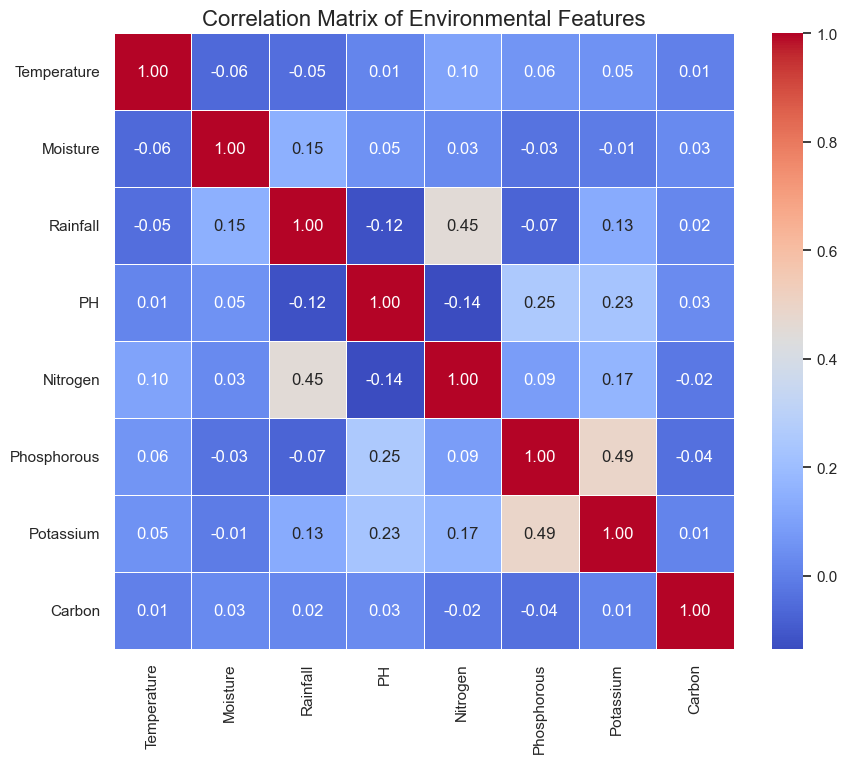

In [68]:
# Calculate the correlation matrix (drop non-numeric 'Fertilizer' column)
corr_matrix = df.drop(columns=["Soil", "Crop", "Fertilizer", "Remark"], axis=1).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Environmental Features', fontsize=16)
plt.savefig('4_correlation_heatmap.png')
plt.show()

### 5. Summary of EDA and Next Steps (New Section)

**Key Findings:**
1.  **Data Quality:** The dataset is clean of nulls and duplicates, but contained impossible negative values for `Rainfall`, `Phosphorous`, `Potassium`, and `Carbon`. These have been corrected by replacing them with 0.
2.  **Target Variable (`Fertilizer`):** The target variable is highly **imbalanced**, with 'DAP' and 'Water Retaining Fertilizer' dominating. This will require balancing techniques (e.g., SMOTE) or careful metric selection (e.g., F1-Score) for modeling.
3.  **Feature Analysis:**
    * `Remark`: This column is a textual description of the `Fertilizer` and is redundant. It should be dropped.
    * `Soil`: This is an important categorical feature with 5 types. Its distribution and relationship with `Fertilizer` have been visualized.
    * `Crop`: This is a key categorical feature with 34 unique crops.
    * **Nutrient Relationships:** The boxplots clearly show that recommendations for 'Urea' (high N), 'DAP' (high P), and 'Muriate of Potash' (high K) correspond to soils with lower levels of those respective nutrients. 'Lime' and 'Gypsum' are correctly associated with low (acidic) and high (alkaline) PH values, respectively.
4.  **Correlations:** The numerical features do not show very strong correlations with each other, except for a moderate positive correlation (0.45) between `Rainfall` and `Nitrogen`. This suggests multicollinearity won't be a major issue.

**Proposed Next Steps (Preprocessing):**
1.  **Drop Redundant Column:** Remove the `Remark` column.
2.  **Encoding:**
    * Apply **Label Encoding** to the target variable `Fertilizer`.
    * Apply **One-Hot Encoding** (or `pd.get_dummies`) to the categorical features `Soil` and `Crop`, as they are nominal.
3.  **Train/Test Split:** Split the data into `X` (features) and `y` (target), then split into training and testing sets.
4.  **Handle Imbalance:** Apply SMOTE **only to the training data** to rebalance the classes.
5.  **Scaling:** Apply `StandardScaler` or `MinMaxScaler` to the numerical features (`Temperature`, `Moisture`, `Rainfall`, `PH`, `Nitrogen`, `Phosphorous`, `Potassium`, `Carbon`) **after** the train/test split (fit on train, transform on train and test).

The data is now well-understood and a clear plan for preprocessing is established.